# OpenCV MeanShift and CamShift Tutorial: From 0 to Mastery

This notebook follows the style of `OpenCV_From_Zero_to_Master_ATDL_Style_fixed.ipynb`: theory first, runnable local demos second, then debugging rules, practice tasks, and references.

本 notebook 用“从 0 到精通”的路线讲清楚 MeanShift 和 CamShift。你会学到：

- 为什么颜色直方图可以做追踪
- 什么是 histogram backprojection / 直方图反向投影
- MeanShift 如何在概率图上移动固定窗口
- CamShift 如何自动更新窗口大小和角度
- 为什么算法会漂移、变大、追错目标
- 如何把它们放进真实视频或摄像头循环

Core mindset:

`tracking = detection once + localization repeatedly + failure handling`

## How to Use This Notebook

Recommended learning order:

1. Read Part 1 to build the mental model.
2. Run Part 2 cell by cell and inspect every visualization.
3. Modify target color, background clutter, ROI size, motion speed, and histogram settings.
4. Use Part 3 as a debugging checklist and project roadmap.

Suggested environment:

- Python 3.10+
- `opencv-python`
- `numpy`
- `matplotlib`

This notebook creates synthetic frames locally, so no video download is required.

## Part 1: Theoretical Foundations

### 1.1 What Problem Are They Solving?

In many video tasks, we select an object once and then want to keep following it.

Typical pipeline:

1. Select initial ROI.
2. Convert ROI to HSV.
3. Build a target color histogram.
4. For each new frame, compute histogram backprojection.
5. Run MeanShift or CamShift on that probability image.
6. Draw the updated tracking result.

The key idea:

`Do not track raw pixels directly. Track a probability map that says where the target color is likely to be.`

### 1.2 HSV, Histogram, and Backprojection

OpenCV images are usually BGR, but color tracking often works better in HSV:

- `H`: hue, roughly the color type
- `S`: saturation, color purity
- `V`: brightness

A target histogram stores which colors are common in the selected ROI. Backprojection then asks every pixel in a new frame:

`How likely is my color under the target histogram?`

The output is a grayscale probability-like image:

- bright = likely target
- dark = unlikely target

Practical rule:

- use `H` only when target color is distinctive
- use `(H, S)` when hue alone is ambiguous
- mask low saturation / low brightness pixels because their hue is unstable

### 1.3 MeanShift: Fixed-Size Mode Seeking

MeanShift is an iterative mode-seeking algorithm. In tracking:

1. Start from a window `(x, y, w, h)`.
2. Look at probability values inside the window.
3. Compute the weighted center of mass.
4. Move the window center toward that mass.
5. Repeat until movement is tiny or max iteration count is reached.

OpenCV API:

```python
num_iters, track_window = cv2.meanShift(back_project, track_window, term_crit)
```

Important limitation:

`MeanShift moves the window, but the window size stays fixed.`

### 1.4 CamShift: Adaptive MeanShift

CamShift means **Continuously Adaptive Mean Shift**.

It starts from MeanShift, then estimates the size and orientation of the probability blob. OpenCV returns:

```python
rotated_rect, track_window = cv2.CamShift(back_project, track_window, term_crit)
```

`rotated_rect` contains center, width, height, and angle. It can be drawn with:

```python
box = cv2.boxPoints(rotated_rect)
box = np.intp(box)
cv2.polylines(frame, [box], True, color, 2)
```

MeanShift is simpler and stable for fixed-size objects. CamShift is better when the object changes scale or rotates, but it can over-expand when the background has similar colors.

### 1.5 Failure Modes

MeanShift and CamShift often fail when:

- target color is not distinctive
- background has similar colors
- lighting changes strongly
- object is occluded
- object moves too fast
- initial ROI includes too much background
- HSV mask removes useful target pixels
- CamShift expands onto a distractor

Master-level habit:

`Always inspect the backprojection map. If backprojection is wrong, the tracker cannot be right.`

## Part 2: Coding Demo - Build the Tracker Step by Step

### 2.1 Imports and Helpers

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
except ImportError as exc:
    raise ImportError("OpenCV is not installed. Please run: pip install opencv-python") from exc

print("OpenCV version:", cv2.__version__)
print("Working directory:", os.getcwd())


def show_many(images, cols=3, figsize=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for idx, (title, image, cmap) in enumerate(images, start=1):
        plt.subplot(rows, cols, idx)
        if image.ndim == 2:
            plt.imshow(image, cmap=cmap or "gray")
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def draw_window(frame, window, color=(0, 255, 0), label=None):
    x, y, w, h = [int(v) for v in window]
    vis = frame.copy()
    cv2.rectangle(vis, (x, y), (x + w, y + h), color, 2)
    if label:
        cv2.putText(vis, label, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return vis


def draw_rotated_rect(frame, rotated_rect, color=(255, 0, 255), label=None):
    vis = frame.copy()
    box = cv2.boxPoints(rotated_rect)
    box = np.intp(box)
    cv2.polylines(vis, [box], True, color, 2)
    if label:
        cx, cy = rotated_rect[0]
        cv2.putText(vis, label, (int(cx), int(cy)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return vis

OpenCV version: 4.13.0
Working directory: /home/ubuntu/Documents/ComputerVision


### 2.2 Create a Synthetic Tracking Sequence

We generate a small video-like sequence. The target moves, rotates, and grows. The background contains a similar-colored distractor so the tracker has something realistic to struggle with.

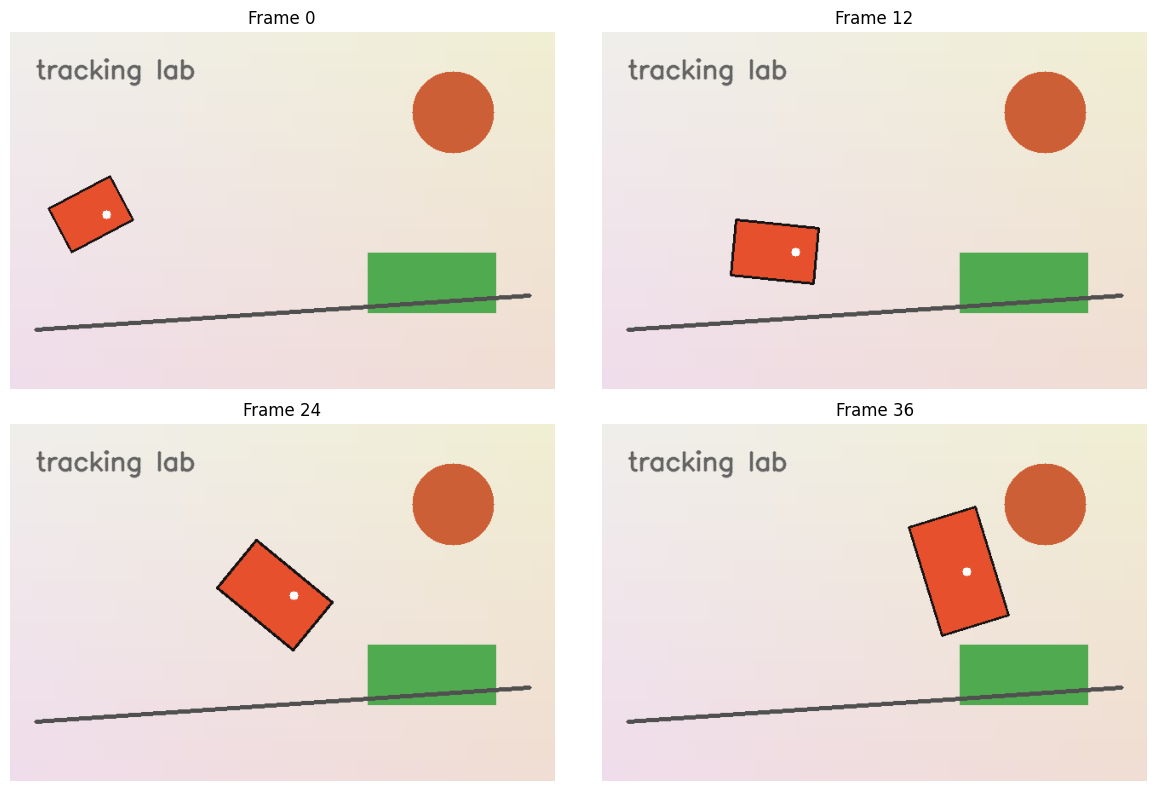

Number of frames: 42
Initial ground-truth window: (45, 170, 100, 90)


In [3]:
def make_tracking_frame(t, size=(420, 640), target_bgr=(45, 80, 230), clutter=True):
    h, w = size
    frame = np.full((h, w, 3), (235, 238, 240), dtype=np.uint8)
    x_grad = np.linspace(0, 25, w, dtype=np.uint8)
    y_grad = np.linspace(0, 18, h, dtype=np.uint8)[:, None]
    frame[:, :, 0] = np.clip(frame[:, :, 0] - x_grad, 0, 255)
    frame[:, :, 1] = np.clip(frame[:, :, 1] - y_grad, 0, 255)

    if clutter:
        cv2.circle(frame, (520, 95), 48, (55, 95, 205), -1)
        cv2.rectangle(frame, (420, 260), (570, 330), (80, 170, 80), -1)
        cv2.line(frame, (30, 350), (610, 310), (80, 80, 80), 3)
        cv2.putText(frame, "tracking lab", (30, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (100, 100, 100), 2, cv2.LINE_AA)

    cx = int(95 + 9.0 * t)
    cy = int(215 + 45 * np.sin(t / 7.0))
    tw = int(82 + 1.4 * t)
    th = int(58 + 0.65 * t)
    angle = float(-28 + 2.8 * t)

    rect = ((cx, cy), (tw, th), angle)
    box = np.intp(cv2.boxPoints(rect))
    cv2.fillConvexPoly(frame, box, target_bgr)
    cv2.polylines(frame, [box], True, (20, 20, 20), 2)
    cv2.circle(frame, (cx + int(0.25 * tw * np.cos(np.deg2rad(angle))), cy), 5, (255, 255, 255), -1)
    return frame, cv2.boundingRect(box), rect


frames, gt_windows, gt_rects = [], [], []
for t in range(42):
    frame, win, rect = make_tracking_frame(t)
    frames.append(frame)
    gt_windows.append(win)
    gt_rects.append(rect)

show_many(
    [("Frame 0", frames[0], None), ("Frame 12", frames[12], None),
     ("Frame 24", frames[24], None), ("Frame 36", frames[36], None)],
    cols=2,
    figsize=(12, 8),
)
print("Number of frames:", len(frames))
print("Initial ground-truth window:", gt_windows[0])

### 2.3 Build the Target Histogram

In real projects the first ROI may come from mouse selection, a detector, or a previous pipeline step. Here we use the synthetic ground truth for frame 0.

Good ROI rule:

`The initial box should contain mostly target pixels and as little background as possible.`

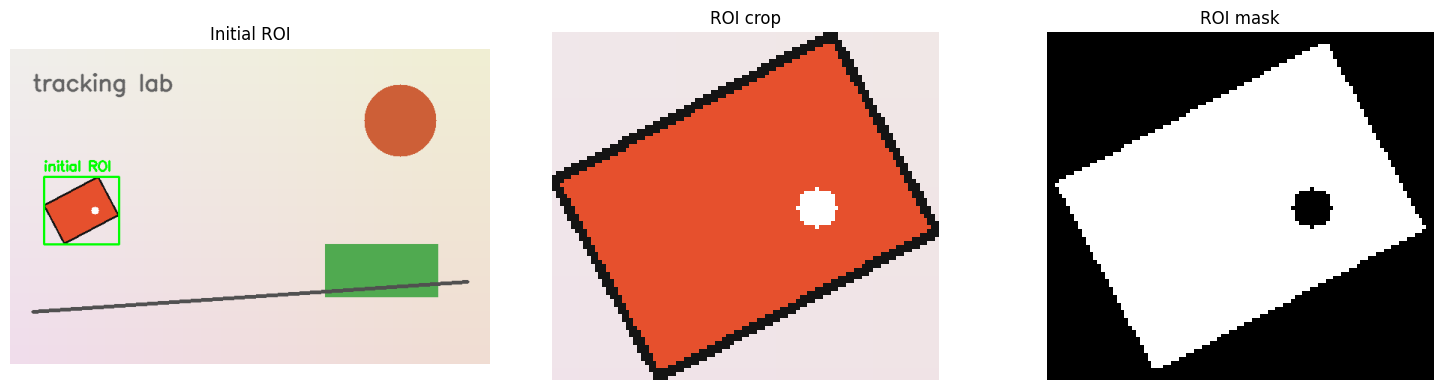

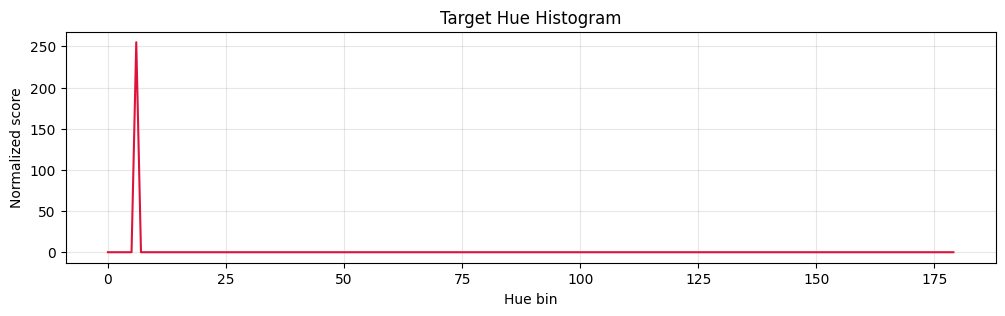

In [4]:
initial_frame = frames[0]
x, y, w, h = gt_windows[0]
initial_window = (x, y, w, h)
roi = initial_frame[y:y + h, x:x + w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
roi_mask = cv2.inRange(roi_hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))

roi_hist = cv2.calcHist([roi_hsv], [0], roi_mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

show_many(
    [("Initial ROI", draw_window(initial_frame, initial_window, label="initial ROI"), None),
     ("ROI crop", roi, None), ("ROI mask", roi_mask, "gray")],
    cols=3,
    figsize=(15, 4),
)
plt.figure(figsize=(12, 3))
plt.plot(roi_hist, color="crimson")
plt.title("Target Hue Histogram")
plt.xlabel("Hue bin")
plt.ylabel("Normalized score")
plt.grid(True, alpha=0.3)
plt.show()

### 2.4 Backprojection

Backprojection converts a frame into a probability map. Bright pixels are likely to belong to the target color model.

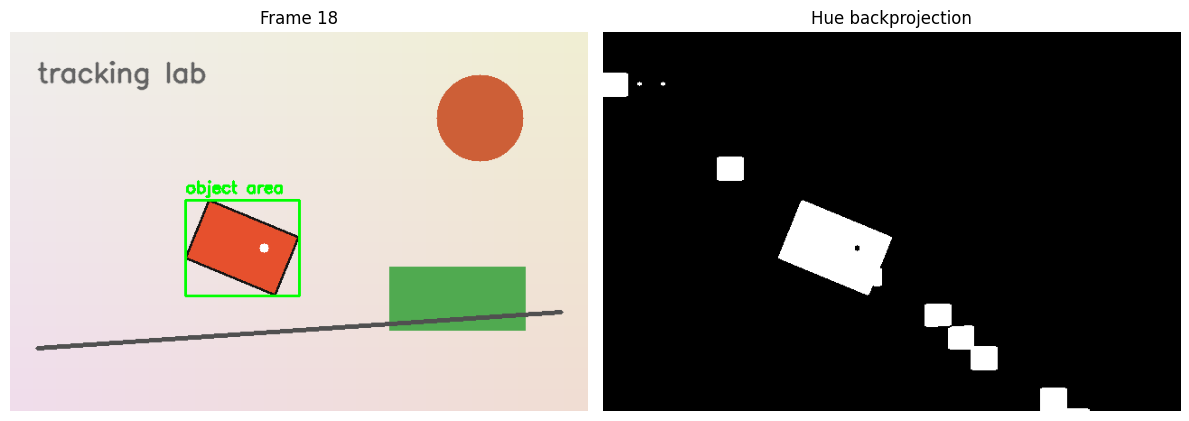

Backprojection range: 0 to 255


In [5]:
def hue_backprojection(frame_bgr, hist):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    back_project = cv2.calcBackProject([hsv], [0], hist, [0, 180], 1)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.filter2D(back_project, -1, kernel)


sample_index = 18
sample_back_project = hue_backprojection(frames[sample_index], roi_hist)
show_many(
    [(f"Frame {sample_index}", draw_window(frames[sample_index], gt_windows[sample_index], label="object area"), None),
     ("Hue backprojection", sample_back_project, "gray")],
    cols=2,
    figsize=(12, 5),
)
print("Backprojection range:", int(sample_back_project.min()), "to", int(sample_back_project.max()))

### 2.5 MeanShift Tracking

MeanShift moves the current window toward the probability peak. The window size stays fixed.

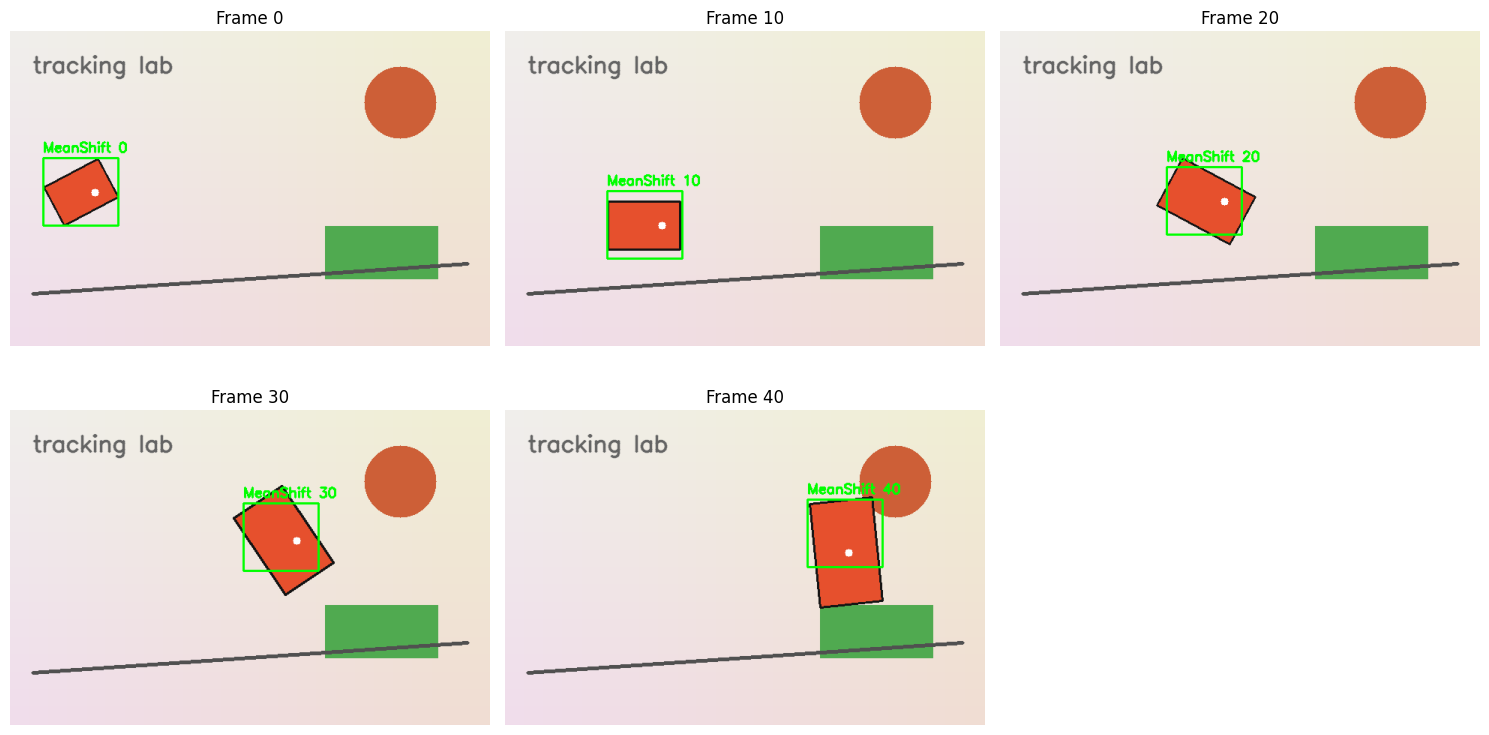

Final MeanShift window: (413, 124, 100, 90)


In [6]:
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 12, 1)
mean_window = initial_window
meanshift_windows, meanshift_visuals = [], []

for idx, frame in enumerate(frames):
    back_project = hue_backprojection(frame, roi_hist)
    _, mean_window = cv2.meanShift(back_project, mean_window, term_crit)
    meanshift_windows.append(mean_window)
    if idx in [0, 10, 20, 30, 40]:
        meanshift_visuals.append((f"Frame {idx}", draw_window(frame, mean_window, label=f"MeanShift {idx}"), None))

show_many(meanshift_visuals, cols=3, figsize=(15, 8))
print("Final MeanShift window:", meanshift_windows[-1])

### 2.6 CamShift Tracking

CamShift uses the same probability map, but returns an adaptive rotated rectangle.

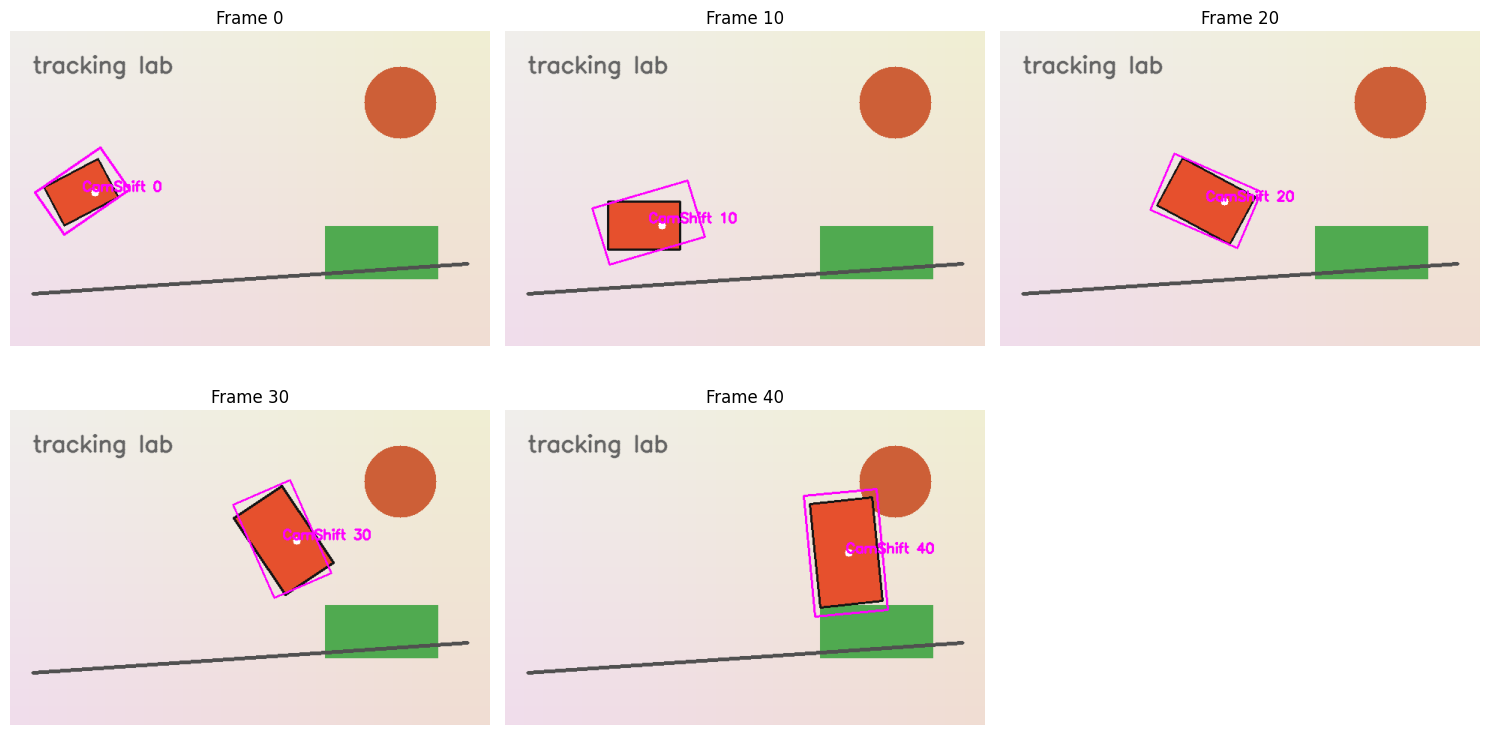

Final CamShift window: (413, 113, 100, 164)
Final CamShift rotated rect: ((463.0, 195.0), (98.42239379882812, 161.93507385253906), 177.06072998046875)


In [7]:
cam_window = initial_window
camshift_rects, camshift_windows, camshift_visuals = [], [], []

for idx, frame in enumerate(frames):
    back_project = hue_backprojection(frame, roi_hist)
    rotated_rect, cam_window = cv2.CamShift(back_project, cam_window, term_crit)
    camshift_rects.append(rotated_rect)
    camshift_windows.append(cam_window)
    if idx in [0, 10, 20, 30, 40]:
        camshift_visuals.append((f"Frame {idx}", draw_rotated_rect(frame, rotated_rect, label=f"CamShift {idx}"), None))

show_many(camshift_visuals, cols=3, figsize=(15, 8))
print("Final CamShift window:", camshift_windows[-1])
print("Final CamShift rotated rect:", camshift_rects[-1])

### 2.7 Side-by-Side Comparison and Center Error

Expected observation:

- MeanShift follows the target but keeps the original window size.
- CamShift follows the target and adapts its size and angle.

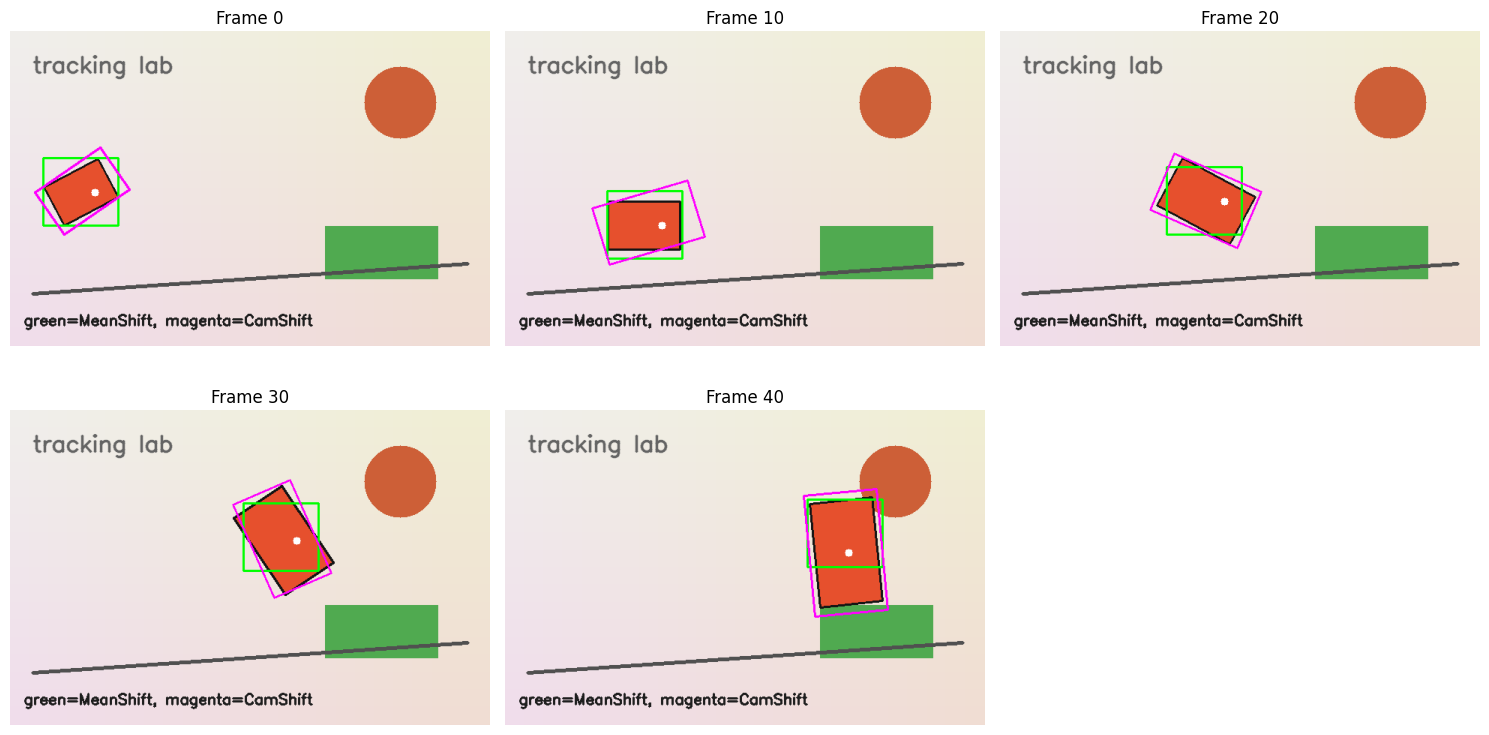

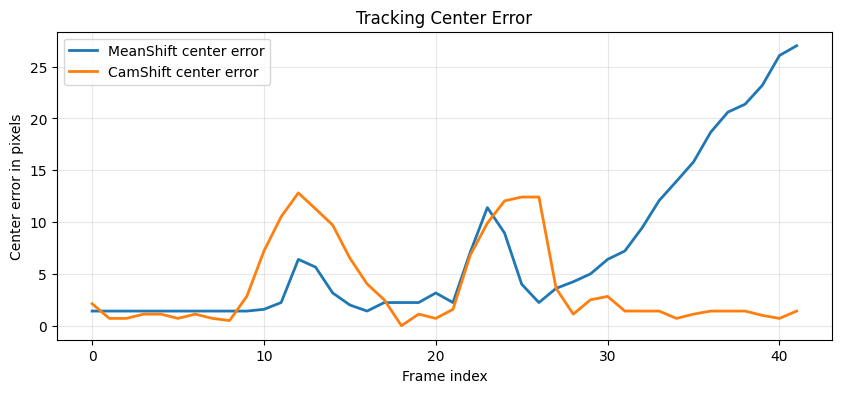

MeanShift average center error: 7.07 px
CamShift average center error:  3.73 px


In [8]:
comparison_visuals = []
for idx in [0, 10, 20, 30, 40]:
    vis = frames[idx].copy()
    x, y, w, h = meanshift_windows[idx]
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
    box = np.intp(cv2.boxPoints(camshift_rects[idx]))
    cv2.polylines(vis, [box], True, (255, 0, 255), 2)
    cv2.putText(vis, "green=MeanShift, magenta=CamShift", (18, 392), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (30, 30, 30), 2)
    comparison_visuals.append((f"Frame {idx}", vis, None))
show_many(comparison_visuals, cols=3, figsize=(15, 8))

def window_center(window):
    x, y, w, h = window
    return np.array([x + w / 2.0, y + h / 2.0], dtype=np.float32)

mean_errors, cam_errors = [], []
for gt, mean_win, cam_rect in zip(gt_windows, meanshift_windows, camshift_rects):
    gt_c = window_center(gt)
    mean_errors.append(float(np.linalg.norm(window_center(mean_win) - gt_c)))
    cam_errors.append(float(np.linalg.norm(np.array(cam_rect[0], dtype=np.float32) - gt_c)))

plt.figure(figsize=(10, 4))
plt.plot(mean_errors, label="MeanShift center error", linewidth=2)
plt.plot(cam_errors, label="CamShift center error", linewidth=2)
plt.xlabel("Frame index")
plt.ylabel("Center error in pixels")
plt.title("Tracking Center Error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print(f"MeanShift average center error: {np.mean(mean_errors):.2f} px")
print(f"CamShift average center error:  {np.mean(cam_errors):.2f} px")

### 2.8 Masked Backprojection and ROI Quality

Two common improvements:

1. Use an HSV mask to suppress unstable dark/gray pixels.
2. Avoid polluted initial ROIs that include too much background.

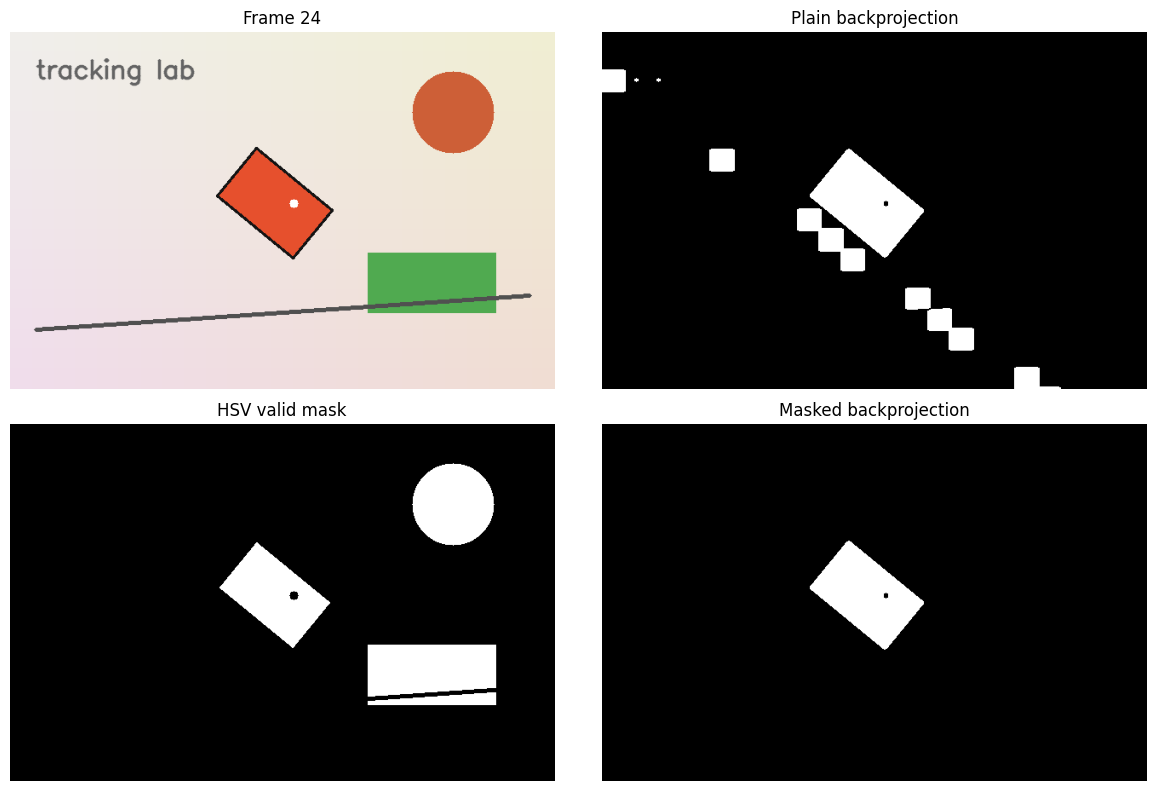

In [9]:
def masked_hue_backprojection(frame_bgr, hist, lower=(0, 45, 45), upper=(180, 255, 255)):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    back_project = cv2.calcBackProject([hsv], [0], hist, [0, 180], 1)
    mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
    back_project = cv2.bitwise_and(back_project, back_project, mask=mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.filter2D(back_project, -1, kernel), mask


frame_idx = 24
bp_plain = hue_backprojection(frames[frame_idx], roi_hist)
bp_masked, valid_mask = masked_hue_backprojection(frames[frame_idx], roi_hist)
show_many(
    [(f"Frame {frame_idx}", frames[frame_idx], None), ("Plain backprojection", bp_plain, "gray"),
     ("HSV valid mask", valid_mask, "gray"), ("Masked backprojection", bp_masked, "gray")],
    cols=2,
    figsize=(12, 8),
)

### 2.9 Reusable Tracker Function and Parameter Lab

The function below makes the algorithm choice explicit. After that, we compare a clean initial ROI with a deliberately polluted one.

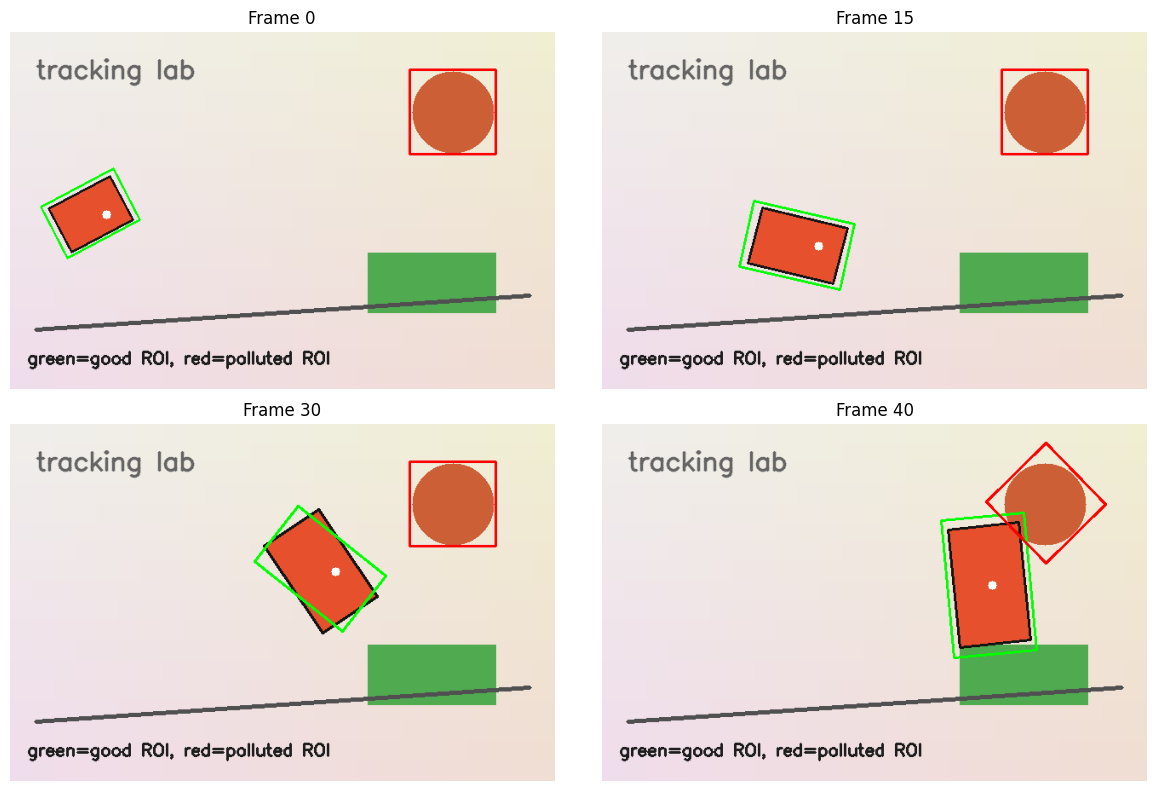

In [10]:
def run_color_tracker(frames, initial_window, hist, method="camshift", use_mask=True):
    term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 12, 1)
    track_window = tuple(int(v) for v in initial_window)
    records = []
    for idx, frame in enumerate(frames):
        back_project = masked_hue_backprojection(frame, hist)[0] if use_mask else hue_backprojection(frame, hist)
        if method.lower() == "meanshift":
            _, track_window = cv2.meanShift(back_project, track_window, term_crit)
            records.append({"frame_index": idx, "window": track_window, "rotated_rect": None})
        elif method.lower() == "camshift":
            rotated_rect, track_window = cv2.CamShift(back_project, track_window, term_crit)
            records.append({"frame_index": idx, "window": track_window, "rotated_rect": rotated_rect})
        else:
            raise ValueError("method must be 'meanshift' or 'camshift'")
    return records


def build_hue_histogram(frame, window, sat_min=40, val_min=40, bins=180):
    x, y, w, h = [int(v) for v in window]
    roi = frame[y:y + h, x:x + w]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array((0, sat_min, val_min)), np.array((180, 255, 255)))
    hist = cv2.calcHist([hsv], [0], mask, [bins], [0, 180])
    cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)
    return hist


bad_initial_window = (max(0, x - 35), max(0, y - 35), w + 70, h + 70)
records_good = run_color_tracker(frames, initial_window, build_hue_histogram(initial_frame, initial_window))
records_bad = run_color_tracker(frames, bad_initial_window, build_hue_histogram(initial_frame, bad_initial_window))

visuals = []
for idx in [0, 15, 30, 40]:
    vis = frames[idx].copy()
    good_box = np.intp(cv2.boxPoints(records_good[idx]["rotated_rect"]))
    bad_box = np.intp(cv2.boxPoints(records_bad[idx]["rotated_rect"]))
    cv2.polylines(vis, [good_box], True, (0, 255, 0), 2)
    cv2.polylines(vis, [bad_box], True, (0, 0, 255), 2)
    cv2.putText(vis, "green=good ROI, red=polluted ROI", (20, 390), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (30, 30, 30), 2)
    visuals.append((f"Frame {idx}", vis, None))
show_many(visuals, cols=2, figsize=(12, 8))

### 2.10 Optional: 2D Hue-Saturation Histogram

Hue-only tracking is simple. A `(H, S)` histogram can be more discriminative when the background has similar hue but different saturation.

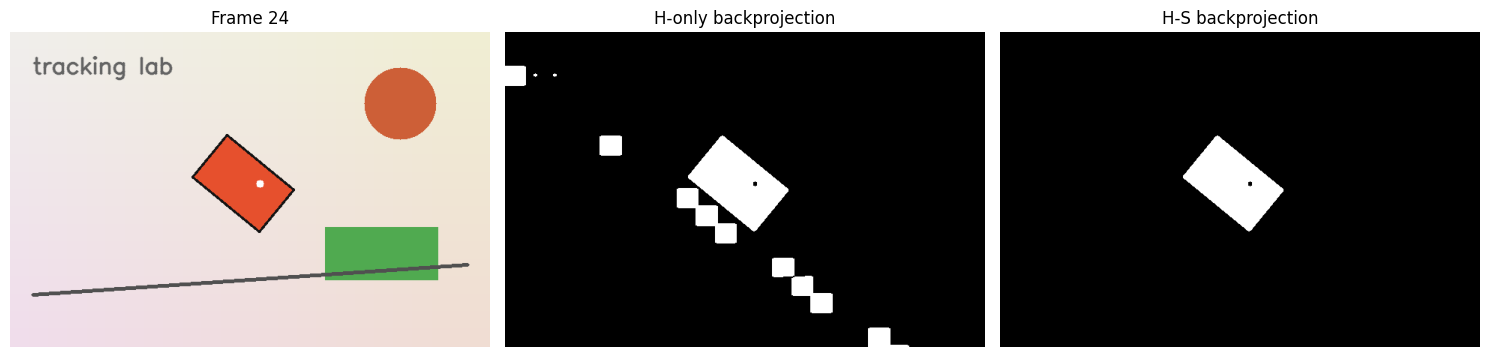

In [11]:
def build_hs_histogram(frame, window, h_bins=30, s_bins=32):
    x, y, w, h = [int(v) for v in window]
    roi = frame[y:y + h, x:x + w]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))
    hist = cv2.calcHist([hsv], [0, 1], mask, [h_bins, s_bins], [0, 180, 0, 256])
    cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)
    return hist


def hs_backprojection(frame_bgr, hist):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    back_project = cv2.calcBackProject([hsv], [0, 1], hist, [0, 180, 0, 256], 1)
    mask = cv2.inRange(hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))
    back_project = cv2.bitwise_and(back_project, back_project, mask=mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    return cv2.filter2D(back_project, -1, kernel)


hs_hist = build_hs_histogram(initial_frame, initial_window)
frame_idx = 24
show_many(
    [(f"Frame {frame_idx}", frames[frame_idx], None),
     ("H-only backprojection", hue_backprojection(frames[frame_idx], roi_hist), "gray"),
     ("H-S backprojection", hs_backprojection(frames[frame_idx], hs_hist), "gray")],
    cols=3,
    figsize=(15, 4),
)

### 2.11 Template for Real Video or Webcam Tracking

This cell prints a safe template instead of automatically opening your camera.

In [12]:
video_tracking_template = r'''
import cv2
import numpy as np

cap = cv2.VideoCapture(0)  # or replace 0 with a video path
if not cap.isOpened():
    raise RuntimeError("Cannot open video source")

ok, frame = cap.read()
if not ok:
    raise RuntimeError("Cannot read first frame")

x, y, w, h = cv2.selectROI("Select target", frame, fromCenter=False, showCrosshair=True)
cv2.destroyWindow("Select target")
track_window = (int(x), int(y), int(w), int(h))

roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
roi_mask = cv2.inRange(roi_hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))
roi_hist = cv2.calcHist([roi_hsv], [0], roi_mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while True:
    ok, frame = cap.read()
    if not ok:
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_project = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
    valid_mask = cv2.inRange(hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))
    back_project = cv2.bitwise_and(back_project, back_project, mask=valid_mask)

    rotated_rect, track_window = cv2.CamShift(back_project, track_window, term_crit)
    box = np.intp(cv2.boxPoints(rotated_rect))
    cv2.polylines(frame, [box], True, (255, 0, 255), 2)

    cv2.imshow("tracking", frame)
    cv2.imshow("backprojection", back_project)
    if (cv2.waitKey(30) & 0xFF) == 27:
        break

cap.release()
cv2.destroyAllWindows()
'''
print(video_tracking_template)


import cv2
import numpy as np

cap = cv2.VideoCapture(0)  # or replace 0 with a video path
if not cap.isOpened():
    raise RuntimeError("Cannot open video source")

ok, frame = cap.read()
if not ok:
    raise RuntimeError("Cannot read first frame")

x, y, w, h = cv2.selectROI("Select target", frame, fromCenter=False, showCrosshair=True)
cv2.destroyWindow("Select target")
track_window = (int(x), int(y), int(w), int(h))

roi = frame[y:y+h, x:x+w]
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
roi_mask = cv2.inRange(roi_hsv, np.array((0, 40, 40)), np.array((180, 255, 255)))
roi_hist = cv2.calcHist([roi_hsv], [0], roi_mask, [180], [0, 180])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while True:
    ok, frame = cap.read()
    if not ok:
        break
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    back_project = cv2.calcBackProject([hsv], [0], roi_hist, [0, 180], 1)
    valid_mask = cv2.inRange(hsv,

## Part 3: Debugging and Mastery Roadmap

Debug in this order:

1. **Initial ROI**: mostly object, little background.
2. **HSV mask**: target not accidentally removed.
3. **Histogram**: target has a clear peak.
4. **Backprojection**: target is bright, distractors are darker.
5. **Search window**: object remains inside the local search area.
6. **Motion speed**: large jumps may lose the local mode.
7. **CamShift size**: over-expansion usually means background color pollution.

Ways to improve reliability:

- use `(H, S)` histogram when hue alone is weak
- clean backprojection with morphology
- add confidence scoring, such as `back_project[y:y+h, x:x+w].mean()`
- reinitialize with a detector when confidence drops
- combine with optical flow or Kalman filtering for smoother motion

## Part 4: Practice Projects

Suggested progression:

1. **Single-color object tracker**: track a marker or ball from webcam.
2. **ROI quality experiment**: compare tight, loose, and bad initial ROIs.
3. **Backprojection debugger**: show frame, HSV mask, backprojection, and result side by side.
4. **Detector + CamShift hybrid**: detector initializes, CamShift tracks between detections.
5. **Failure recovery**: stop or reinitialize when confidence is low.
6. **Multi-object version**: one histogram and one window per object.

## Part 5: Quick API Reference

Core OpenCV functions:

- `cv2.cvtColor(image, cv2.COLOR_BGR2HSV)`
- `cv2.inRange(hsv, lower, upper)`
- `cv2.calcHist(images, channels, mask, histSize, ranges)`
- `cv2.normalize(src, dst, alpha, beta, norm_type)`
- `cv2.calcBackProject(images, channels, hist, ranges, scale)`
- `cv2.meanShift(probImage, window, criteria)`
- `cv2.CamShift(probImage, window, criteria)`
- `cv2.boxPoints(rotatedRect)`
- `cv2.selectROI(windowName, image)`

Official references:

- OpenCV Python Meanshift and Camshift tutorial: https://docs.opencv.org/4.x/d7/d00/tutorial_meanshift.html
- OpenCV histogram backprojection tutorial: https://docs.opencv.org/4.x/dc/df6/tutorial_py_histogram_backprojection.html
- OpenCV video analysis module documentation: https://docs.opencv.org/4.x/d7/df3/group__imgproc__motion.html

## Conclusion

MeanShift and CamShift teach the core loop of classical tracking:

`represent target -> score new frame -> update state -> visualize -> handle failure`

MeanShift is the clean fixed-window version. CamShift is the adaptive version that estimates scale and rotation. Once you understand them, more advanced trackers become easier to reason about.